# 范哲齐-25361077-第三次作业运行结果

**分析主题：** 公交 IC 卡刷卡数据分析  
**使用库：** NumPy、pandas、matplotlib、seaborn

In [1]:
%matplotlib inline
"""
公交IC卡数据分析
姓名：范哲齐
学号：25361077
"""

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "ICData.csv").exists():
    candidate = PROJECT_DIR / "范哲齐-25361077-第三次人工智能编程作业"
    if candidate.exists():
        PROJECT_DIR = candidate
DATA_FILE = PROJECT_DIR / "ICData.csv"

def print_task(n, title):
    print("\n" + "=" * 72)
    print(f"任务{n}  {title}")
    print("=" * 72)


## 任务1：数据预处理

In [ ]:
def load_data(csv_path=DATA_FILE):
    print_task(1, "数据预处理")

    # 读取CSV文件，编码用utf-8-sig防止中文列名前面带BOM
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    print("数据集前5行：")
    print(df.head().to_string(index=False))
    print(f"\n基本信息：{df.shape[0]} 行，{df.shape[1]} 列")
    print("各列初始数据类型：")
    print(df.dtypes.to_string())

    # 把"交易时间"列从字符串转成datetime类型，errors="coerce"表示无法解析的会变成NaT
    df["交易时间"] = pd.to_datetime(df["交易时间"], errors="coerce")
    # 从datetime里面提取小时部分，新增hour列，后面按时段统计要用
    df["hour"] = df["交易时间"].dt.hour
    # 计算搭乘站点数：下车站点减去上车站点，取绝对值
    df["ride_stops"] = (df["下车站点"] - df["上车站点"]).abs()

    # ride_stops为0说明上下车站相同，属于异常记录，要删掉
    n_zero = (df["ride_stops"] == 0).sum()
    df = df[df["ride_stops"] > 0].copy()
    print(f"\n删除 ride_stops=0 的异常记录：{n_zero} 行")

    # 检查各列有没有缺失值
    print("各列缺失值数量：")
    print(df.isna().sum().to_string())
    n_before = len(df)
    # 如果存在缺失值就把那一行整行删掉
    df = df.dropna().copy()
    print(f"删除含缺失值的记录：{n_before - len(df)} 行")

    df["hour"] = df["hour"].astype(int)
    print(f"预处理后有效记录：{len(df)} 行")
    return df

df = load_data()

## 任务2：时间分布分析

In [ ]:
def analyze_time_distribution(df):
    print_task(2, "时间分布分析")

    # 只保留刷卡类型=0的记录（即上车刷卡），后续任务也是同样的筛选
    boardings = df[df["刷卡类型"] == 0].copy()
    # 把hour列从pandas Series转成numpy一维数组，后面用numpy布尔索引做筛选
    hours = boardings["hour"].to_numpy(dtype=int)

    # numpy布尔索引：hours < 7生成True/False数组，用它来筛选早峰前时段的数据
    early = hours[hours < 7]
    # 同理筛选出22点及以后的深夜时段数据
    late = hours[hours >= 22]
    total = len(hours)

    print(f"全天上车刷卡量：{total} 次")
    print(f"早峰前时段（hour < 7）：{len(early)} 次，占比 {len(early)/total*100:.2f}%")
    print(f"深夜时段（hour >= 22）：{len(late)} 次，占比 {len(late)/total*100:.2f}%")

    # np.bincount统计数组中每个整数值出现了多少次（0到23各出现几次）
    counts = np.bincount(hours, minlength=24)[:24]
    # np.arange生成0到23的数组，作为x轴坐标
    hour_vals = np.arange(24)
    # np.where实现条件赋值：小于7用蓝色，大于等于22用红色，其余用青色
    colors = np.where(hour_vals < 7, "#4C78A8",
                      np.where(hour_vals >= 22, "#E45756", "#72B7B2"))

    # 使用matplotlib直接画柱状图（不能用seaborn替代）
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(hour_vals, counts, color=colors, edgecolor="white", linewidth=0.7)
    ax.set_title("24-Hour Boarding Distribution", fontsize=15, pad=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Number of Boardings")
    ax.set_xticks(np.arange(0, 24, 2))
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#4C78A8", label="Before 07:00"),
        Patch(color="#72B7B2", label="07:00-21:59"),
        Patch(color="#E45756", label="22:00 and later")
    ], frameon=False)

    fig.tight_layout()
    path = PROJECT_DIR / "hour_distribution.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"24小时分布图已保存：{path}")
    plt.show()
    plt.close(fig)
    return boardings, counts

boardings, hourly_counts = analyze_time_distribution(df)

## 任务3：线路站点分析

In [ ]:
def analyze_route_stops(df, route_col='线路号', stops_col='ride_stops'):
    """
    计算各线路乘客的平均搭乘站点数及其标准差。

    Parameters
    ----------
    df : pd.DataFrame
        预处理后的数据集
    route_col : str
        线路号列名
    stops_col : str
        搭乘站点数列名

    Returns
    -------
    pd.DataFrame
        包含列：线路号、mean_stops、std_stops，按 mean_stops 降序排列
    """
    # 按线路号分组，对搭乘站点数分别求均值和标准差
    stats = df.groupby(route_col, as_index=False)[stops_col].agg(
        mean_stops="mean", std_stops="std"
    ).sort_values("mean_stops", ascending=False).reset_index(drop=True)
    # 只有一条记录的线路标准差会是NaN，填充为0
    stats["std_stops"] = stats["std_stops"].fillna(0.0)
    return stats

def plot_route_stops(boardings):
    print_task(3, "线路站点分析")
    stats = analyze_route_stops(boardings)
    print("各线路搭乘站点数统计（前10行）：")
    print(stats.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # 取均值最高的前15条线路用于可视化
    top15 = stats.head(15).copy()
    top15["线路标签"] = top15["线路号"].astype(str)
    labels = top15["线路标签"].tolist()
    plot_df = boardings[boardings["线路号"].isin(top15["线路号"])].copy()
    plot_df["线路标签"] = plot_df["线路号"].astype(str)

    fig, ax = plt.subplots(figsize=(10, 7))
    opts = dict(data=plot_df, x="ride_stops", y="线路标签", hue="线路标签",
                order=labels, hue_order=labels, estimator=np.mean,
                capsize=0.3, palette="Blues_d", dodge=False, ax=ax)
    # 兼容seaborn新旧版本：新版用errorbar参数，旧版用ci参数
    try:
        sns.barplot(**opts, errorbar="sd")
    except (TypeError, AttributeError):
        sns.barplot(**opts, ci="sd")

    legend = ax.get_legend()
    if legend:
        legend.remove()

    ax.set_title("Top 15 Routes by Average Ride Stops", fontsize=15, pad=12)
    ax.set_xlabel("Average Number of Ride Stops")
    ax.set_ylabel("Route")
    ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    path = PROJECT_DIR / "route_stops.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"线路站点分析图已保存：{path}")
    plt.show()
    plt.close(fig)
    return stats

route_stats = plot_route_stops(boardings)

## 任务4：高峰小时系数计算

In [ ]:
def analyze_peak_hour_factors(boardings, hourly_counts=None):
    print_task(4, "高峰小时系数计算")

    # 如果没有传入各小时的计数，就重新统计一次
    if hourly_counts is None:
        hourly_counts = np.bincount(boardings["hour"].to_numpy(dtype=int), minlength=24)[:24]

    # 用argmax找到刷卡量最大的那个小时的索引（自动识别，不是写死的）
    peak_h = np.argmax(hourly_counts)
    # 筛选出高峰小时内的所有上车刷卡记录
    peak_df = boardings[boardings["hour"] == peak_h].copy()
    # 高峰小时的总刷卡量，即PHF公式中的分子
    peak_vol = len(peak_df)

    # 把交易时间设为索引并排序，resample要求索引必须是DatetimeIndex
    timeline = peak_df.set_index("交易时间").sort_index()

    # ---- 5分钟粒度统计 ----
    # resample("5min")将这一小时划分为12个5分钟的时间窗口
    # size()统计每个窗口里有多少条记录
    c5 = timeline.resample("5min").size()
    # idxmax()得到最大值所在窗口的起始时间点
    max5_start = c5.idxmax()
    # 取出12个窗口中的最大刷卡量
    max5_vol = c5.max()
    # 套公式：PHF5 = 高峰小时总量 / (12 × 最大5分钟量)
    # 12是因为1小时里有12个5分钟
    phf5 = peak_vol / (12 * max5_vol)

    # ---- 15分钟粒度统计 ----
    # resample("15min")将这一小时划分为4个15分钟的时间窗口
    c15 = timeline.resample("15min").size()
    max15_start = c15.idxmax()
    max15_vol = c15.max()
    # 套公式：PHF15 = 高峰小时总量 / (4 × 最大15分钟量)
    # 4是因为1小时里有4个15分钟
    phf15 = peak_vol / (4 * max15_vol)

    # 按照作业要求的格式输出完整计算过程
    print(f"高峰小时：{peak_h:02d}:00 ~ {(peak_h+1)%24:02d}:00，刷卡量：{peak_vol} 次")
    print(f"最大5分钟刷卡量（{max5_start:%H:%M}~{max5_start+pd.Timedelta(minutes=5):%H:%M}）：{max5_vol} 次")
    print(f"PHF5  = {peak_vol} / (12 × {max5_vol}) = {phf5:.4f}")
    print(f"最大15分钟刷卡量（{max15_start:%H:%M}~{max15_start+pd.Timedelta(minutes=15):%H:%M}）：{max15_vol} 次")
    print(f"PHF15 = {peak_vol} / ( 4 × {max15_vol}) = {phf15:.4f}")

    return {
        "peak_hour": peak_h, "peak_volume": peak_vol,
        "max_5_start": max5_start, "max_5_volume": max5_vol, "phf5": phf5,
        "max_15_start": max15_start, "max_15_volume": max15_vol, "phf15": phf15
    }

phf_result = analyze_peak_hour_factors(boardings, hourly_counts)

## 任务5：线路驾驶员信息批量导出

In [6]:
def export_route_driver_info(boardings):
    print_task(5, "线路驾驶员信息批量导出")
    out_dir = PROJECT_DIR / "线路驾驶员信息"
    out_dir.mkdir(parents=True, exist_ok=True)

    old_files = list(out_dir.glob("*.txt"))
    for f in old_files:
        f.unlink()
    if old_files:
        print(f"已清理上次运行的 {len(old_files)} 个旧文件。")

    paths = []
    for route in range(1101, 1121):
        route_df = boardings[boardings["线路号"] == route][["车辆编号", "驾驶员编号"]]
        pairs = route_df.drop_duplicates().astype({"车辆编号": int, "驾驶员编号": int}).sort_values(["车辆编号", "驾驶员编号"])

        lines = [f"线路号: {route}"]
        lines.extend(f"{v}\t{d}" for v, d in pairs.itertuples(index=False, name=None))
        fpath = out_dir / f"{route}.txt"
        fpath.write_text("\n".join(lines) + "\n", encoding="utf-8")
        paths.append(fpath)
        print(f"已生成：{fpath}")

    print(f"共生成 {len(paths)} 个线路驾驶员信息文件。")
    return paths

generated_files = export_route_driver_info(boardings)


任务5  线路驾驶员信息批量导出
已清理上次运行的 20 个旧文件。
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1101.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1102.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1103.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1104.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1105.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1106.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1107.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1108.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1109.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1110.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次

已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1118.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1119.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1120.txt
共生成 20 个线路驾驶员信息文件。


## 任务6：服务绩效排名与热力图


任务6  服务绩效排名与热力图

Driver Top 10：
Top 1       0: 6484 次
Top 2  90422201: 4801 次
Top 3  1090101: 1334 次
Top 4  90417292: 1107 次
Top 5  90805213: 395 次
Top 6     101: 380 次
Top 7  90839201: 369 次
Top 8  9017887: 358 次
Top 9  9011030: 345 次
Top10  9011104: 329 次

Route Top 10：
Top 1   46003: 7127 次
Top 2    1091: 4893 次
Top 3       9: 4474 次
Top 4      88: 4350 次
Top 5       5: 4190 次
Top 6    1101: 3782 次
Top 7   56012: 3736 次
Top 8    1112: 3683 次
Top 9    1114: 3414 次
Top10    1115: 3244 次

Boarding Station Top 10：
Top 1       1: 7776 次
Top 2      14: 6553 次
Top 3      17: 6449 次
Top 4      13: 5990 次
Top 5       8: 5894 次
Top 6       2: 5892 次
Top 7       9: 5813 次
Top 8      10: 5759 次
Top 9      15: 5736 次
Top10      21: 5707 次

Vehicle Top 10：
Top 1       0: 11774 次
Top 2  1000000: 2033 次
Top 3   25263: 604 次
Top 4   25321: 518 次
Top 5   25282: 482 次
Top 6   19683: 444 次
Top 7   17468: 405 次
Top 8   24915: 403 次
Top 9   15506: 402 次
Top10   19881: 399 次

服务绩效热力图已保存：/Users/z7/Desktop

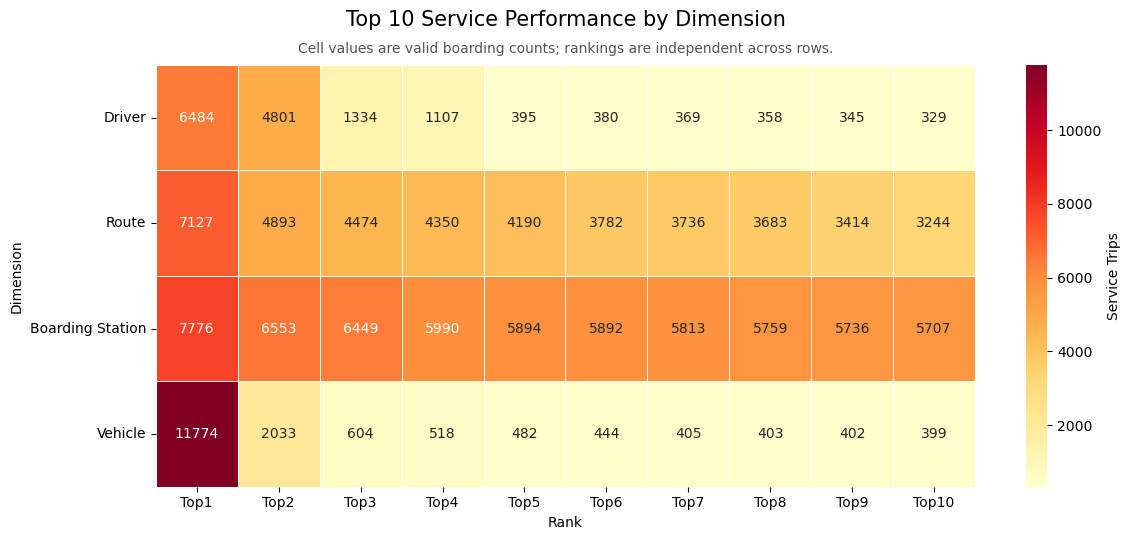

结论说明：
热力图显示，客流在不同服务维度上并不均衡：Top1线路46003共服务7127人次，约为Top10线路的2.20倍；Top1司机0服务6484人次，Top1上车站点1有7776人次，Top1车辆0承载11774人次。线路和车辆的头部值明显高于同组后几名，说明少数核心运营对象承担了较集中的服务量，后续排班和运力配置应重点关注这些高负荷对象。


In [7]:
def analyze_service_performance(boardings):
    print_task(6, "服务绩效排名与热力图")

    cols = {
        "Driver": "驾驶员编号",
        "Route": "线路号",
        "Boarding Station": "上车站点",
        "Vehicle": "车辆编号"
    }
    rankings = {k: boardings[v].value_counts().head(10) for k, v in cols.items()}

    for dim, ranking in rankings.items():
        print(f"\n{dim} Top 10：")
        for i, (entity, cnt) in enumerate(ranking.items(), 1):
            print(f"Top{i:>2}  {int(entity):>6}: {int(cnt)} 次")

    vals = np.vstack([rankings[d].to_numpy(dtype=int) for d in cols])
    heatmap_df = pd.DataFrame(vals, index=list(cols.keys()),
                               columns=[f"Top{i}" for i in range(1, 11)])

    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.heatmap(heatmap_df, annot=True, fmt="d", cmap="YlOrRd",
                linewidths=0.7, linecolor="white",
                cbar_kws={"label": "Service Trips"}, ax=ax)
    ax.set_title("Top 10 Service Performance by Dimension", fontsize=15, pad=28)
    ax.text(0.5, 1.02,
            "Cell values are valid boarding counts; rankings are independent across rows.",
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, color="#555555")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Dimension")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    fig.tight_layout()
    path = PROJECT_DIR / "performance_heatmap.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"\n服务绩效热力图已保存：{path}")
    plt.show()
    plt.close(fig)

    top_driver, top_driver_cnt = rankings["Driver"].index[0], rankings["Driver"].iloc[0]
    top_route, top_route_cnt = rankings["Route"].index[0], rankings["Route"].iloc[0]
    tenth_route_cnt = rankings["Route"].iloc[-1]
    top_station, top_station_cnt = rankings["Boarding Station"].index[0], rankings["Boarding Station"].iloc[0]
    top_vehicle, top_vehicle_cnt = rankings["Vehicle"].index[0], rankings["Vehicle"].iloc[0]
    ratio = top_route_cnt / tenth_route_cnt

    conclusion = (f"热力图显示，客流在不同服务维度上并不均衡：Top1线路{int(top_route)}"
                  f"共服务{int(top_route_cnt)}人次，约为Top10线路的{ratio:.2f}倍；"
                  f"Top1司机{int(top_driver)}服务{int(top_driver_cnt)}人次，"
                  f"Top1上车站点{int(top_station)}有{int(top_station_cnt)}人次，"
                  f"Top1车辆{int(top_vehicle)}承载{int(top_vehicle_cnt)}人次。"
                  "线路和车辆的头部值明显高于同组后几名，说明少数核心运营对象承担了较集中的服务量，"
                  "后续排班和运力配置应重点关注这些高负荷对象。")
    print("结论说明：")
    print(conclusion)
    return rankings, heatmap_df, conclusion

rankings, heatmap_data, conclusion = analyze_service_performance(boardings)